In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def prepare_and_save_pure_datasets(file_path, random_state=42):
    print("====== 1. 載入並過濾資料 (移除 Enrolled) ======")
    df = pd.read_csv(file_path)
    df_filtered = df[df['Target'] != 'Enrolled'].copy()
    
    # 精選的 11 個原始特徵
    selected_features = [
        'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)',
        'Curricular units 1st sem (enrolled)', 'Curricular units 2nd sem (enrolled)',
        'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
        'Scholarship holder', 'Tuition fees up to date',
        'Application mode', 'Admission grade', 'Previous qualification (grade)'
    ]
    X_raw = df_filtered[selected_features].copy()
    
    print("====== 2. 進行特徵工程 (自創 3 個強力特徵) ======")
    X_eng = X_raw.copy()
    X_eng['1st_sem_pass_rate'] = X_raw['Curricular units 1st sem (approved)'] / (X_raw['Curricular units 1st sem (enrolled)'] + 1e-8)
    X_eng['2nd_sem_pass_rate'] = X_raw['Curricular units 2nd sem (approved)'] / (X_raw['Curricular units 2nd sem (enrolled)'] + 1e-8)
    X_eng['grade_change'] = X_raw['Curricular units 2nd sem (grade)'] - X_raw['Curricular units 1st sem (grade)']
    
    # 轉換標籤：Dropout -> 1, Graduate -> 0
    y = (df_filtered['Target'] == 'Dropout').astype(int).values
    
    print("====== 3. 嚴格切分 Train (80%) 與 Test (20%) ======")
    X_train, X_test, y_train, y_test = train_test_split(
        X_eng, y, test_size=0.2, stratify=y, random_state=random_state
    )
    
    print("====== 4. 執行標準化 (防止資訊洩漏的關鍵步驟) ======")
    # 宣告 Scaler
    scaler = StandardScaler()
    
    # 【鐵律】: 只在訓練集上 fit 和 transform
    X_train_scaled = scaler.fit_transform(X_train)
    # 【鐵律】: 測試集絕對只能 transform，偷偷借用訓練集的平均值與標準差
    X_test_scaled = scaler.transform(X_test)
    
    # 轉回 DataFrame，保留欄位名稱（這樣後面找 MinDiff 敏感欄位才方便）
    feature_names = X_train.columns
    train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
    train_scaled_df['Target_Label'] = y_train
    
    test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)
    test_scaled_df['Target_Label'] = y_test
    
    print("====== 5. 將純淨且標準化好的資料落盤儲存 ======")
    train_scaled_df.to_csv('train_scaled.csv', index=False)
    test_scaled_df.to_csv('test_scaled.csv', index=False)
    
    print(f"➔ 成功生成 'train_scaled.csv' (樣本數: {len(train_scaled_df)})")
    print(f"➔ 成功生成 'test_scaled.csv'  (樣本數: {len(test_scaled_df)})")
    print(f"真實世界退學比例 (保持不變): {np.mean(y_train):.2%}")

if __name__ == "__main__":
    prepare_and_save_pure_datasets('data.csv')

====== 1. 載入並過濾資料 (移除 Enrolled) ======
====== 2. 進行特徵工程 (自創 3 個強力特徵) ======
====== 3. 嚴格切分 Train (80%) 與 Test (20%) ======
====== 4. 執行標準化 (防止資訊洩漏的關鍵步驟) ======
====== 5. 將純淨且標準化好的資料落盤儲存 ======
➔ 成功生成 'train_scaled.csv' (樣本數: 2904)
➔ 成功生成 'test_scaled.csv'  (樣本數: 726)
真實世界退學比例 (保持不變): 39.15%


====== 1. 讀取統一標準化後的 CSV 資料 ======
訓練總集規模: (2904, 14) | 獨立測試集規模: (726, 14)

====== 2. 開始執行 5-Fold 交叉驗證訓練 ======
--- 🟢 正在訓練第 1 / 5 折 ---
    第 1 折內部驗證集 AUC: 0.9313
--- 🟢 正在訓練第 2 / 5 折 ---
    第 2 折內部驗證集 AUC: 0.9367
--- 🟢 正在訓練第 3 / 5 折 ---
    第 3 折內部驗證集 AUC: 0.9367
--- 🟢 正在訓練第 4 / 5 折 ---
    第 4 折內部驗證集 AUC: 0.9605
--- 🟢 正在訓練第 5 / 5 折 ---
    第 5 折內部驗證集 AUC: 0.9420

====== 3. 5-Fold 整合效能評估 (測試集結果) ======
🥇 5-Fold 內部平均驗證 AUC: 0.9415 (±0.0101)
🏆 整合模型在黃金測試集的 ROC-AUC: 0.9685

分類報告 (Classification Report):
              precision    recall  f1-score   support

    Graduate       0.94      0.95      0.94       442
     Dropout       0.92      0.90      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.93      0.93       726
weighted avg       0.93      0.93      0.93       726


====== 4. 5-Fold 整合公平性分析 (Fairness Check) ======
📊 [敏感群體] 學費未按時繳納學生的偽陽性率 (FPR): 66.67%
📊 [對照群體] 學費有按時繳納學生的偽陽性率 (FPR): 4.13%
⚠️ 5-Fold 整合公平性差距 (FPR Gap): 62.54%


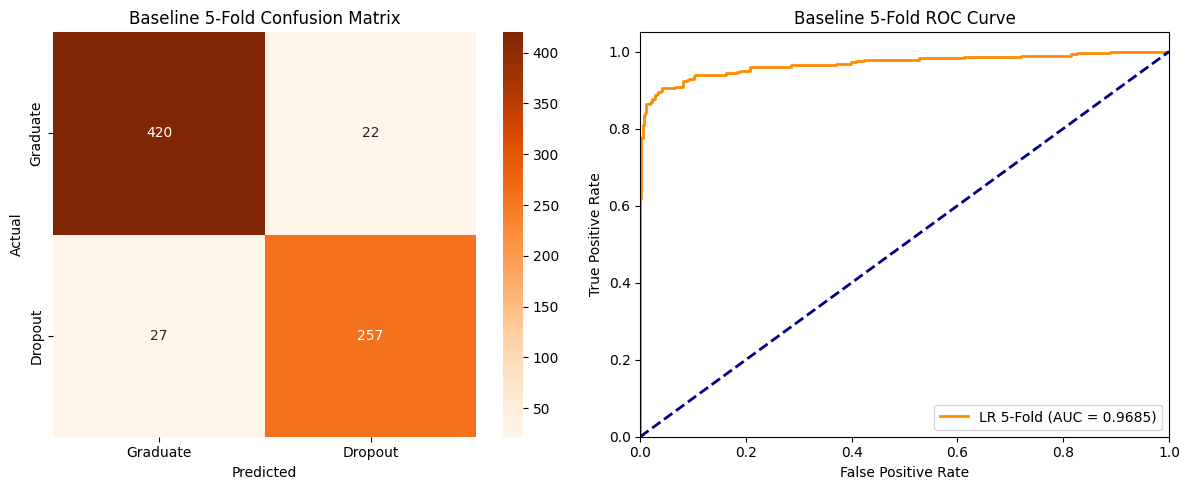

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings

warnings.filterwarnings('ignore')

def run_baseline_kfold_pipeline():
    print("====== 1. 讀取統一標準化後的 CSV 資料 ======")
    try:
        train_df = pd.read_csv('train_scaled.csv')
        test_df = pd.read_csv('test_scaled.csv')
    except FileNotFoundError:
        print("❌ 錯誤：找不到 CSV 檔案，請先執行資料預處理程式碼！")
        return

    # 提取訓練集特徵與標籤
    X_train_full = train_df.drop(columns=['Target_Label'])
    y_train_full = train_df['Target_Label'].values
    
    # 提取獨立黃金測試集特徵與標籤
    X_test = test_df.drop(columns=['Target_Label'])
    y_test = test_df['Target_Label'].values

    print(f"訓練總集規模: {X_train_full.shape} | 獨立測試集規模: {X_test.shape}")

    # =====================================================================
    # 🔄 2. 設定 5-Fold 交叉驗證 (Stratified 保持類別比例)
    # =====================================================================
    print("\n====== 2. 開始執行 5-Fold 交叉驗證訓練 ======")
    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # 用來儲存每一折在「獨立測試集」上的預測結果
    oof_test_probs = np.zeros(len(X_test))
    oof_test_preds = np.zeros(len(X_test))
    
    fold_aucs = []
    fold_gaps = []

    # 定位敏感特徵 'Tuition fees up to date'
    tuition_median = train_df['Tuition fees up to date'].median()

    # 開始跑 5 折迴圈
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
        print(f"--- 🟢 正在訓練第 {fold + 1} / {n_splits} 折 ---")
        
        # 切分當前折的 訓練集 與 內部驗證集
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full[train_idx]
        X_va, y_va = X_train_full.iloc[val_idx], y_train_full[val_idx]
        
        # 初始化並訓練模型
        model = LogisticRegression(solver='liblinear', random_state=42)
        model.fit(X_tr, y_tr)
        
        # 評估當前折在「內部驗證集」上的表現
        val_probs = model.predict_proba(X_va)[:, 1]
        val_auc = roc_auc_score(y_va, val_probs)
        fold_aucs.append(val_auc)
        print(f"    第 {fold + 1} 折內部驗證集 AUC: {val_auc:.4f}")
        
        # 預測「獨立測試集」的機率與類別（累加起來最後取平均）
        oof_test_probs += model.predict_proba(X_test)[:, 1] / n_splits
        oof_test_preds += model.predict(X_test) / n_splits

    # 將類別預測四捨五入轉回 0 或 1
    oof_test_preds = (oof_test_probs > 0.5).astype(int)

    # =====================================================================
    # 🥇 3. 綜合模型效能評估 (Model Evaluation)
    # =====================================================================
    print("\n====== 3. 5-Fold 整合效能評估 (測試集結果) ======")
    baseline_auc = roc_auc_score(y_test, oof_test_probs)
    print(f"🥇 5-Fold 內部平均驗證 AUC: {np.mean(fold_aucs):.4f} (±{np.std(fold_aucs):.4f})")
    print(f"🏆 整合模型在黃金測試集的 ROC-AUC: {baseline_auc:.4f}")
    
    print("\n分類報告 (Classification Report):")
    print(classification_report(y_test, oof_test_preds, target_names=['Graduate', 'Dropout']))

    # =====================================================================
    # ⚖️ 4. 敏感屬性公平性分析 (Fairness Check)
    # =====================================================================
    print("\n====== 4. 5-Fold 整合公平性分析 (Fairness Check) ======")
    
    test_eval_df = pd.DataFrame({
        'True_Label': y_test,
        'Pred_Label': oof_test_preds,
        'Tuition_Scaled': X_test['Tuition fees up to date']
    })
    
    sens_group = test_eval_df[test_eval_df['Tuition_Scaled'] < tuition_median]  # 學費未繳 (0)
    ref_group = test_eval_df[test_eval_df['Tuition_Scaled'] >= tuition_median]  # 學費有繳 (1)

    def calculate_fpr(group_df):
        actual_negatives = group_df[group_df['True_Label'] == 0]
        if len(actual_negatives) == 0: return 0.0
        false_positives = actual_negatives[actual_negatives['Pred_Label'] == 1]
        return len(false_positives) / len(actual_negatives)

    fpr_sens = calculate_fpr(sens_group)
    fpr_ref = calculate_fpr(ref_group)
    fpr_gap = abs(fpr_sens - fpr_ref)

    print(f"📊 [敏感群體] 學費未按時繳納學生的偽陽性率 (FPR): {fpr_sens:.2%}")
    print(f"📊 [對照群體] 學費有按時繳納學生的偽陽性率 (FPR): {fpr_ref:.2%}")
    print(f"⚠️ 5-Fold 整合公平性差距 (FPR Gap): {fpr_gap:.2%}")

    # =====================================================================
    # 📊 5. 繪製視覺化圖表
    # =====================================================================
    plt.figure(figsize=(12, 5))

    # 圖一：混淆矩陣
    plt.subplot(1, 2, 1)
    cm = confusion_matrix(y_test, oof_test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=['Graduate', 'Dropout'], yticklabels=['Graduate', 'Dropout'])
    plt.title('Baseline 5-Fold Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # 圖二：ROC 曲線
    plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_test, oof_test_probs)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'LR 5-Fold (AUC = {baseline_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.title('Baseline 5-Fold ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_baseline_kfold_pipeline()

目前工作裝置: cuda

====== 1. 載入標準化後的 CSV 資料 ======
訓練總集規模: (2904, 14) | 獨立測試集規模: (726, 14)

====== 2. 開始執行 MLP 5-Fold 交叉驗證訓練 ======

--- 🟢 正在訓練第 1 / 5 折 ---
    第 1 折內部驗證完成。驗證集 AUC: 0.9320

--- 🟢 正在訓練第 2 / 5 折 ---
    第 2 折內部驗證完成。驗證集 AUC: 0.9400

--- 🟢 正在訓練第 3 / 5 折 ---
    第 3 折內部驗證完成。驗證集 AUC: 0.9430

--- 🟢 正在訓練第 4 / 5 折 ---
    第 4 折內部驗證完成。驗證集 AUC: 0.9611

--- 🟢 正在訓練第 5 / 5 折 ---
    第 5 折內部驗證完成。驗證集 AUC: 0.9375

====== 3. 5-Fold 整合效能評估 (測試集結果) ======
🥇 5-Fold 內部平均驗證 AUC: 0.9427 (±0.0098)
🏆 整合模型在黃金測試集的 5-Fold ROC-AUC: 0.9730

分類報告 (Classification Report):
              precision    recall  f1-score   support

    Graduate       0.94      0.94      0.94       442
     Dropout       0.91      0.90      0.91       284

    accuracy                           0.93       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726


====== 4. 5-Fold 整合公平性分析 (Fairness Check) ======
📊 [敏感群體] 學費未按時繳納學生的偽陽性率 (FPR): 83.33%
📊 [對照群體] 學費有按時繳納學生的偽陽性率 (FP

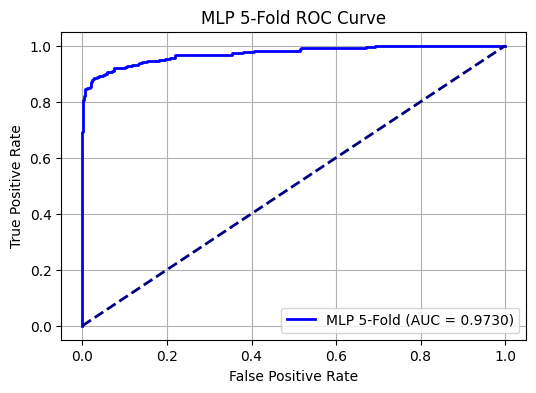

In [20]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 功能類別：Focal Loss 與 早停機制
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.6, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        probs = torch.sigmoid(inputs)
        p_t = torch.where(torch.eq(targets, 1), probs, 1 - probs)
        
        alpha_t = torch.where(torch.eq(targets, 1), 
                              torch.tensor(self.alpha).to(inputs.device), 
                              torch.tensor(1 - self.alpha).to(inputs.device))
        
        loss = alpha_t * (1 - p_t)**self.gamma * bce_loss
        return loss.mean()

class EarlyStopping:
    def __init__(self, patience=10, delta=0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        self.best_model_state = model.state_dict()
        self.val_loss_min = val_loss

# ==========================================
# 2. 神經網路架構 (MLP)
# ==========================================
class DropoutNN(nn.Module):
    def __init__(self, input_dim):
        super(DropoutNN, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.layer_stack(x)

# ==========================================
# 3. 5-Fold 主訓練與評估流程
# ==========================================
def train_mlp_kfold_pipeline():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"目前工作裝置: {device}")

    print("\n====== 1. 載入標準化後的 CSV 資料 ======")
    try:
        train_df = pd.read_csv('train_scaled.csv')
        test_df = pd.read_csv('test_scaled.csv')
    except FileNotFoundError:
        print("❌ 錯誤：找不到 CSV 檔案，請先執行資料預處理程式碼！")
        return

    # 切分完整訓練集特徵與標籤
    X_train_full = train_df.drop(columns=['Target_Label']).values
    y_train_full = train_df['Target_Label'].values
    
    # 獨立黃金測試集
    X_test_np = test_df.drop(columns=['Target_Label']).values
    y_test_np = test_df['Target_Label'].values

    print(f"訓練總集規模: {X_train_full.shape} | 獨立測試集規模: {X_test_np.shape}")

    # ==========================================
    # 🔄 設定 5-Fold 交叉驗證
    # ==========================================
    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # 用來存放 5 折模型對「黃金測試集」預測的機率總和
    oof_test_probs = np.zeros(len(X_test_np))
    fold_val_aucs = []

    print(f"\n====== 2. 開始執行 MLP {n_splits}-Fold 交叉驗證訓練 ======")
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
        print(f"\n--- 🟢 正在訓練第 {fold + 1} / {n_splits} 折 ---")
        
        # 切分當前折的 訓練集 與 內部驗證集
        X_tr, y_tr = X_train_full[train_idx], y_train_full[train_idx]
        X_val, y_val = X_train_full[val_idx], y_train_full[val_idx]
        
        # 建立 PyTorch DataLoader
        train_dataset = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1))
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        
        # 初始化模型與配備
        model = DropoutNN(input_dim=X_tr.shape[1]).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        criterion = FocalLoss(alpha=0.6, gamma=2)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        early_stopping = EarlyStopping(patience=10)
        
        epochs = 100
        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            for b_x, b_y in train_loader:
                b_x, b_y = b_x.to(device), b_y.to(device)
                optimizer.zero_grad()
                outputs = model(b_x)
                loss = criterion(outputs, b_y)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            
            # 內部驗證集評估
            model.eval()
            with torch.no_grad():
                val_x_t = torch.tensor(X_val, dtype=torch.float32).to(device)
                val_y_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)
                v_loss = criterion(model(val_x_t), val_y_t).item()
            
            scheduler.step(v_loss)
            early_stopping(v_loss, model)
            
            if early_stopping.early_stop:
                break
                
        # 載入當前折的最佳權重
        model.load_state_dict(early_stopping.best_model_state)
        
        # 計算當前折在內部驗證集的 AUC 記錄下來
        model.eval()
        with torch.no_grad():
            val_logits = model(torch.tensor(X_val, dtype=torch.float32).to(device))
            val_probs = torch.sigmoid(val_logits).cpu().numpy().squeeze()
            fold_val_aucs.append(roc_auc_score(y_val, val_probs))
            
            # 預測「獨立黃金測試集」的機率（累加）
            test_x_t = torch.tensor(X_test_np, dtype=torch.float32).to(device)
            test_logits = model(test_x_t)
            oof_test_probs += torch.sigmoid(test_logits).cpu().numpy().squeeze() / n_splits
            
        print(f"    第 {fold + 1} 折內部驗證完成。驗證集 AUC: {fold_val_aucs[-1]:.4f}")

    # ==========================================
    # 🥇 4. 黃金測試集效能評估
    # ==========================================
    print("\n====== 3. 5-Fold 整合效能評估 (測試集結果) ======")
    test_preds = (oof_test_probs > 0.5).astype(int)
    mlp_auc = roc_auc_score(y_test_np, oof_test_probs)
    
    print(f"🥇 5-Fold 內部平均驗證 AUC: {np.mean(fold_val_aucs):.4f} (±{np.std(fold_val_aucs):.4f})")
    print(f"🏆 整合模型在黃金測試集的 5-Fold ROC-AUC: {mlp_auc:.4f}")
    print("\n分類報告 (Classification Report):")
    print(classification_report(y_test_np, test_preds, target_names=['Graduate', 'Dropout']))

    # ==========================================
    # ⚖️ 5. 敏感屬性公平性分析 (Fairness Check)
    # ==========================================
    print("\n====== 4. 5-Fold 整合公平性分析 (Fairness Check) ======")
    feature_names = list(train_df.drop(columns=['Target_Label']).columns)
    tuition_col_idx = feature_names.index('Tuition fees up to date')
    tuition_median = train_df['Tuition fees up to date'].median()

    test_eval_df = pd.DataFrame({
        'True_Label': y_test_np,
        'Pred_Label': test_preds,
        'Tuition_Scaled': X_test_np[:, tuition_col_idx]
    })

    sens_group = test_eval_df[test_eval_df['Tuition_Scaled'] < tuition_median]  # 學費未繳
    ref_group = test_eval_df[test_eval_df['Tuition_Scaled'] >= tuition_median]  # 學費有繳

    def calculate_fpr(group_df):
        actual_negatives = group_df[group_df['True_Label'] == 0]
        if len(actual_negatives) == 0: return 0.0
        false_positives = actual_negatives[actual_negatives['Pred_Label'] == 1]
        return len(false_positives) / len(actual_negatives)

    fpr_sens = calculate_fpr(sens_group)
    fpr_ref = calculate_fpr(ref_group)
    fpr_gap = abs(fpr_sens - fpr_ref)

    print(f"📊 [敏感群體] 學費未按時繳納學生的偽陽性率 (FPR): {fpr_sens:.2%}")
    print(f"📊 [對照群體] 學費有按時繳納學生的偽陽性率 (FPR): {fpr_ref:.2%}")
    print(f"⚠️ 5-Fold 整合公平性差距 (FPR Gap): {fpr_gap:.2%}")

    # ====== 6. 繪製 ROC 曲線 =====
    plt.figure(figsize=(6, 4))
    fpr_curve, tpr_curve, _ = roc_curve(y_test_np, oof_test_probs)
    plt.plot(fpr_curve, tpr_curve, color='blue', lw=2, label=f'MLP 5-Fold (AUC = {mlp_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('MLP 5-Fold ROC Curve')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(); plt.grid(True)
    plt.show()

if __name__ == "__main__":
    train_mlp_kfold_pipeline()

🚀 目前工作裝置: cuda

====== 🔥 階段 1：啟動 Optuna 尋找最佳公平超參數 ======

🏆 Optuna 搜尋結束！尋獲之黃金超參數組合：
  ✨ lr: 0.000221
  ✨ beta: 1.332106
  ✨ dropout_1: 0.292656
  ✨ dropout_2: 0.322018

====== 🔄 階段 2：使用黃金超參數進行最終 5-Fold 整合訓練 ======
--- 🟢 正在訓練最終模型 第 1 / 5 折 ---
--- 🟢 正在訓練最終模型 第 2 / 5 折 ---
--- 🟢 正在訓練最終模型 第 3 / 5 折 ---
--- 🟢 正在訓練最終模型 第 4 / 5 折 ---
--- 🟢 正在訓練最終模型 第 5 / 5 折 ---

====== 🏁 階段 3：黃金測試集最終效能與公平性報告 ======
📊 5-Fold 內部平均驗證 AUC: 0.9268 (±0.0146)
📊 5-Fold 內部平均驗證 Gap: 22.67% (±18.32%)
🏆 混合模型在黃金測試集的整合 ROC-AUC: 0.9495

分類報告 (Classification Report):
              precision    recall  f1-score   support

    Graduate       0.94      0.91      0.92       442
     Dropout       0.87      0.90      0.89       284

    accuracy                           0.91       726
   macro avg       0.90      0.91      0.91       726
weighted avg       0.91      0.91      0.91       726

✨ [敏感群體 (學費未繳)] 測試集偽陽性率 (FPR): 16.67%
✨ [對照群體 (學費有繳)] 測試集偽陽性率 (FPR): 8.49%
👑 MinDiff+Optuna 最終修復後的公平性差距 (FPR Gap): 8.18%


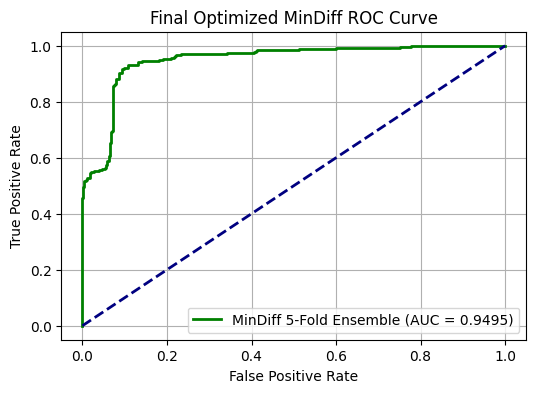

In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING) # 隱藏過多的 Optuna 訓練日誌

# ==========================================
# 1. 核心損失函數與功能類別
# ==========================================
class MmdLoss(nn.Module):
    def __init__(self, sigma=1.0):
        super(MmdLoss, self).__init__()
        self.sigma = sigma

    def rbf_kernel(self, x, y):
        # 展開維度以利用 PyTorch 廣播機制計算距離矩陣
        x = x.unsqueeze(1) 
        y = y.unsqueeze(0) 
        tst = (x - y).pow(2).sum(2)
        return torch.exp(-tst / (2 * self.sigma ** 2))

    def forward(self, x, y):
        xx = self.rbf_kernel(x, x).mean()
        yy = self.rbf_kernel(y, y).mean()
        xy = self.rbf_kernel(x, y).mean()
        return xx + yy - 2 * xy

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.6, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        probs = torch.sigmoid(inputs)
        p_t = torch.where(torch.eq(targets, 1), probs, 1 - probs)
        
        alpha_t = torch.where(torch.eq(targets, 1), 
                              torch.tensor(self.alpha).to(inputs.device), 
                              torch.tensor(1 - self.alpha).to(inputs.device))
        
        loss = alpha_t * (1 - p_t)**self.gamma * bce_loss
        return loss.mean()

class EarlyStopping:
    def __init__(self, patience=8, delta=0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        self.best_model_state = model.state_dict()

# ==========================================
# 2. 動態神經網路架構 (支援 Optuna 調整 Dropout)
# ==========================================
class DynamicDropoutNN(nn.Module):
    def __init__(self, input_dim, dropout_1, dropout_2):
        super(DynamicDropoutNN, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_1),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.layer_stack(x)

# ==========================================
# 3. 輔助計算指標工具
# ==========================================
def compute_fpr_gap(labels, preds, tuition_scaled, tuition_median):
    eval_df = pd.DataFrame({
        'True_Label': labels, 'Pred_Label': preds, 'Tuition_Scaled': tuition_scaled
    })
    sens_group = eval_df[eval_df['Tuition_Scaled'] < tuition_median]
    ref_group = eval_df[eval_df['Tuition_Scaled'] >= tuition_median]
    
    def get_fpr(df):
        neg = df[df['True_Label'] == 0]
        if len(neg) == 0: return 0.0
        return len(neg[neg['Pred_Label'] == 1]) / len(neg)
        
    return abs(get_fpr(sens_group) - get_fpr(ref_group))

# ==========================================
# 4. Optuna 5-Fold 交叉驗證客觀優化目標
# ==========================================
def objective(trial, X_train_full, y_train_full, sens_train_full, tuition_col_idx, tuition_median, device):
    # 定義優化超參數搜尋範圍
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    beta = trial.suggest_float('beta', 0.1, 2.0) # 懲罰權重
    dropout_1 = trial.suggest_float('dropout_1', 0.2, 0.5)
    dropout_2 = trial.suggest_float('dropout_2', 0.1, 0.4)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []
    
    for train_idx, val_idx in skf.split(X_train_full, y_train_full):
        X_tr, y_tr, sens_tr = X_train_full[train_idx], y_train_full[train_idx], sens_train_full[train_idx]
        X_va, y_va, sens_va = X_train_full[val_idx], y_train_full[val_idx], sens_train_full[val_idx]
        
        train_dataset = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32), 
            torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1),
            torch.tensor(sens_tr, dtype=torch.float32).unsqueeze(1)
        )
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        
        model = DynamicDropoutNN(X_train_full.shape[1], dropout_1, dropout_2).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        criterion_focal = FocalLoss(alpha=0.6, gamma=2)
        criterion_mindiff = MmdLoss(sigma=1.0)
        early_stopping = EarlyStopping(patience=8)
        
        for epoch in range(60): # 調參時 epoch 設短，加速搜尋
            model.train()
            for b_x, b_y, b_sens in train_loader:
                b_x, b_y, b_sens = b_x.to(device), b_y.to(device), b_sens.to(device)
                optimizer.zero_grad()
                logits = model(b_x)
                focal_loss = criterion_focal(logits, b_y)
                
                probs = torch.sigmoid(logits)
                sens_mask = (b_sens == 1).squeeze()
                ref_mask = (b_sens == 0).squeeze()
                
                mindiff_loss = criterion_mindiff(probs[sens_mask], probs[ref_mask]) if (sens_mask.sum() > 1 and ref_mask.sum() > 1) else 0.0
                total_loss = focal_loss + beta * mindiff_loss
                total_loss.backward()
                optimizer.step()
            
            # 內部驗證
            model.eval()
            with torch.no_grad():
                val_x_t = torch.tensor(X_va, dtype=torch.float32).to(device)
                val_y_t = torch.tensor(y_va, dtype=torch.float32).unsqueeze(1).to(device)
                v_loss = criterion_focal(model(val_x_t), val_y_t).item()
            early_stopping(v_loss, model)
            if early_stopping.early_stop: break
            
        model.load_state_dict(early_stopping.best_model_state)
        model.eval()
        with torch.no_grad():
            v_logits = model(torch.tensor(X_va, dtype=torch.float32).to(device))
            v_probs = torch.sigmoid(v_logits).cpu().numpy().squeeze()
        
        v_preds = (v_probs > 0.5).astype(int)
        v_auc = roc_auc_score(y_va, v_probs)
        v_gap = compute_fpr_gap(y_va, v_preds, X_va[:, tuition_col_idx], tuition_median)
        
        # 核心優化目標：追求高 AUC 且低 Gap
        fold_scores.append(v_auc - v_gap)
        
    return np.mean(fold_scores)

# ==========================================
# 5. 主執行管道
# ==========================================
def run_mindiff_optuna_pipeline():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 目前工作裝置: {device}")

    train_df = pd.read_csv('train_scaled.csv')
    test_df = pd.read_csv('test_scaled.csv')

    feature_names = list(train_df.drop(columns=['Target_Label']).columns)
    tuition_col_idx = feature_names.index('Tuition fees up to date')
    tuition_median = train_df['Tuition fees up to date'].median()

    X_train_full = train_df.drop(columns=['Target_Label']).values
    y_train_full = train_df['Target_Label'].values
    X_test_np = test_df.drop(columns=['Target_Label']).values
    y_test_np = test_df['Target_Label'].values

    # 生成受保護敏感標籤 (1代表未繳學費的弱勢群體)
    sens_train_full = (X_train_full[:, tuition_col_idx] < tuition_median).astype(np.float32)

    print("\n====== 🔥 階段 1：啟動 Optuna 尋找最佳公平超參數 ======")
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X_train_full, y_train_full, sens_train_full, 
                                           tuition_col_idx, tuition_median, device), n_trials=15)
    
    best_params = study.best_params
    print("\n🏆 Optuna 搜尋結束！尋獲之黃金超參數組合：")
    for k, v in best_params.items():
        print(f"  ✨ {k}: {v:.6f}" if isinstance(v, float) else f"  ✨ {k}: {v}")

    print("\n====== 🔄 階段 2：使用黃金超參數進行最終 5-Fold 整合訓練 ======")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_test_probs = np.zeros(len(X_test_np))
    final_val_aucs = []
    final_val_gaps = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
        print(f"--- 🟢 正在訓練最終模型 第 {fold + 1} / 5 折 ---")
        X_tr, y_tr, sens_tr = X_train_full[train_idx], y_train_full[train_idx], sens_train_full[train_idx]
        X_va, y_va, sens_va = X_train_full[val_idx], y_train_full[val_idx], sens_train_full[val_idx]

        train_dataset = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32), 
            torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1),
            torch.tensor(sens_tr, dtype=torch.float32).unsqueeze(1)
        )
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

        model = DynamicDropoutNN(X_train_full.shape[1], best_params['dropout_1'], best_params['dropout_2']).to(device)
        optimizer = optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=1e-4)
        criterion_focal = FocalLoss(alpha=0.6, gamma=2)
        criterion_mindiff = MmdLoss(sigma=1.0)
        early_stopping = EarlyStopping(patience=10)

        for epoch in range(100): # 最終訓練允許更長充裕的收斂時間
            model.train()
            for b_x, b_y, b_sens in train_loader:
                b_x, b_y, b_sens = b_x.to(device), b_y.to(device), b_sens.to(device)
                optimizer.zero_grad()
                logits = model(b_x)
                focal_loss = criterion_focal(logits, b_y)
                
                probs = torch.sigmoid(logits)
                sens_mask = (b_sens == 1).squeeze()
                ref_mask = (b_sens == 0).squeeze()
                
                mindiff_loss = criterion_mindiff(probs[sens_mask], probs[ref_mask]) if (sens_mask.sum() > 1 and ref_mask.sum() > 1) else 0.0
                total_loss = focal_loss + best_params['beta'] * mindiff_loss
                total_loss.backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                val_x_t = torch.tensor(X_va, dtype=torch.float32).to(device)
                val_y_t = torch.tensor(y_va, dtype=torch.float32).unsqueeze(1).to(device)
                v_loss = criterion_focal(model(val_x_t), val_y_t).item()
            early_stopping(v_loss, model)
            if early_stopping.early_stop: break

        # 載入該折最優狀態，並對獨立測試集進行預測
        model.load_state_dict(early_stopping.best_model_state)
        model.eval()
        with torch.no_grad():
            # 記錄內部驗證指標
            v_logits = model(torch.tensor(X_va, dtype=torch.float32).to(device))
            v_probs = torch.sigmoid(v_logits).cpu().numpy().squeeze()
            final_val_aucs.append(roc_auc_score(y_va, v_probs))
            final_val_gaps.append(compute_fpr_gap(y_va, (v_probs > 0.5).astype(int), X_va[:, tuition_col_idx], tuition_median))
            
            # 對黃金測試集進行軟投票累加
            t_logits = model(torch.tensor(X_test_np, dtype=torch.float32).to(device))
            oof_test_probs += torch.sigmoid(t_logits).cpu().numpy().squeeze() / 5.0

    # ==========================================
    # 🥇 6. 最終黃金測試集整合效能評估
    # ==========================================
    print("\n====== 🏁 階段 3：黃金測試集最終效能與公平性報告 ======")
    final_preds = (oof_test_probs > 0.5).astype(int)
    test_auc = roc_auc_score(y_test_np, oof_test_probs)

    print(f"📊 5-Fold 內部平均驗證 AUC: {np.mean(final_val_aucs):.4f} (±{np.std(final_val_aucs):.4f})")
    print(f"📊 5-Fold 內部平均驗證 Gap: {np.mean(final_val_gaps):.2%} (±{np.std(final_val_gaps):.2%})")
    print(f"🏆 混合模型在黃金測試集的整合 ROC-AUC: {test_auc:.4f}")
    print("\n分類報告 (Classification Report):")
    print(classification_report(y_test_np, final_preds, target_names=['Graduate', 'Dropout']))

    # 公平性計算
    test_eval_df = pd.DataFrame({
        'True_Label': y_test_np, 'Pred_Label': final_preds, 'Tuition_Scaled': X_test_np[:, tuition_col_idx]
    })
    sens_group = test_eval_df[test_eval_df['Tuition_Scaled'] < tuition_median]
    ref_group = test_eval_df[test_eval_df['Tuition_Scaled'] >= tuition_median]

    def get_group_fpr(df):
        neg = df[df['True_Label'] == 0]
        return 0.0 if len(neg) == 0 else len(neg[neg['Pred_Label'] == 1]) / len(neg)

    fpr_sens = get_group_fpr(sens_group)
    fpr_ref = get_group_fpr(ref_group)
    fpr_gap = abs(fpr_sens - fpr_ref)

    print(f"✨ [敏感群體 (學費未繳)] 測試集偽陽性率 (FPR): {fpr_sens:.2%}")
    print(f"✨ [對照群體 (學費有繳)] 測試集偽陽性率 (FPR): {fpr_ref:.2%}")
    print(f"👑 MinDiff+Optuna 最終修復後的公平性差距 (FPR Gap): {fpr_gap:.2%}")

    # 繪製最終整合模型的 ROC 曲線
    plt.figure(figsize=(6, 4))
    fpr_curve, tpr_curve, _ = roc_curve(y_test_np, oof_test_probs)
    plt.plot(fpr_curve, tpr_curve, color='green', lw=2, label=f'MinDiff 5-Fold Ensemble (AUC = {test_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('Final Optimized MinDiff ROC Curve')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(); plt.grid(True)
    plt.show()

if __name__ == "__main__":
    run_mindiff_optuna_pipeline()